# 2. Logistic Regression Baseline

First full-data Logistic Regression fit: stratified 80/20 split, `class_weight='balanced'`, confusion matrix, overall metrics, and coefficient interpretation.

In [1]:
import sys
from pathlib import Path

# Find the project root regardless of what VS Code / Jupyter set as the
# working directory (VS Code defaults notebooks to the workspace root,
# not the notebook's own folder, so ".." alone isn't reliable).
cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)

from src.models import get_logistic_regression
from src.preprocessing import build_logreg_pipeline, load_data, stratified_split

df = load_data()


## 2.1  Why class_weight='balanced'?
Before fitting the final model: does an *unweighted* Logistic Regression just guess the majority class, or does it do something more subtle? (Notebook 01, section 1.2, showed pure majority-class guessing tops out at 49.9% this compares against a real fitted model instead).

In [2]:
X_train, X_test, y_train, y_test = stratified_split(df)

# Logistic Regression WITHOUT class_weight="balanced"
unweighted_model = LogisticRegression(max_iter=1000, random_state=42)
unweighted_pipe = build_logreg_pipeline(unweighted_model)
unweighted_pipe.fit(X_train, y_train)
y_pred_unweighted = unweighted_pipe.predict(X_test)

# Logistic Regression WITH class_weight="balanced" (used for the rest of this notebook)
balanced_pipe = build_logreg_pipeline(get_logistic_regression())
balanced_pipe.fit(X_train, y_train)
y_pred_balanced = balanced_pipe.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Unweighted", "class_weight='balanced'"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_unweighted),
        accuracy_score(y_test, y_pred_balanced),
    ],
    "Enrolled Recall": [
        recall_score(y_test, y_pred_unweighted, labels=["Enrolled"], average=None)[0],
        recall_score(y_test, y_pred_balanced, labels=["Enrolled"], average=None)[0],
    ],
})
display(comparison.round(3))

,Model,Accuracy,Enrolled Recall
0,Unweighted,0.771,0.390
1,class_weight='balanced',0.725,0.635


## 2.1 Model fit

In [3]:
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

pipe = balanced_pipe
y_pred = y_pred_balanced

print(classification_report(y_test, y_pred))


Train class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Test class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.74       284
    Enrolled       0.42      0.64      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



## 2.2 Confusion matrix

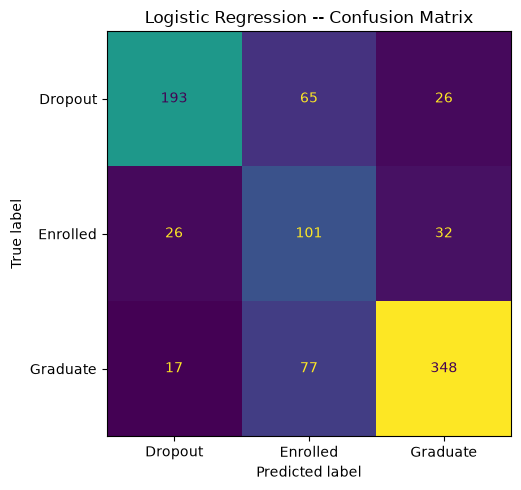

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Logistic Regression -- Confusion Matrix")
plt.tight_layout()
plt.show()


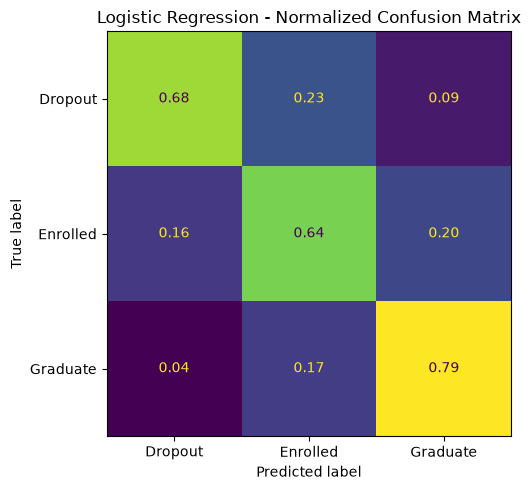

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", values_format=".2f", colorbar=False, ax=ax
)
ax.set_title("Logistic Regression - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


## 2.3 Overall performance metrics

In [6]:
logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_macro_f1 = f1_score(y_test, y_pred, average="macro")
logreg_weighted_f1 = f1_score(y_test, y_pred, average="weighted")
logreg_macro_recall = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy:     {logreg_accuracy:.3f}")
print(f"Macro F1:     {logreg_macro_f1:.3f}")
print(f"Weighted F1:  {logreg_weighted_f1:.3f}")
print(f"Macro Recall: {logreg_macro_recall:.3f}")


Accuracy:     0.725
Macro F1:     0.689
Weighted F1:  0.738
Macro Recall: 0.701


## 2.4 Coefficient interpretation

In [7]:
preprocessor = pipe.named_steps["preprocess"]
logreg_model = pipe.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    logreg_model.coef_, columns=feature_names, index=logreg_model.classes_
)
coef_df.head()


,num__Application order,num__Previous qualification (grade),num__Admission grade,num__Age at enrollment,num__Curricular units 1st sem (credited),num__Curricular units 1st sem (enrolled),num__Curricular units 1st sem (evaluations),num__Curricular units 1st sem (approved),num__Curricular units 1st sem (grade),num__Curricular units 1st sem (without evaluations),...,cat__Father's occupation_194,cat__Father's occupation_195,bin__Daytime/evening attendance,bin__Displaced,bin__Educational special needs,bin__Debtor,bin__Tuition fees up to date,bin__Gender,bin__Scholarship holder,bin__International
Dropout,0.132412,0.014900,-0.004980,0.110735,0.158477,0.296999,-0.036440,-0.861432,0.087111,-0.078891,...,0.049598,-0.005041,0.153710,0.225752,0.095166,0.420615,-1.832913,0.212969,-0.182054,-0.188289
Enrolled,-0.131932,-0.033333,-0.057428,-0.018390,-0.023984,0.253092,0.194691,-0.423616,-0.081606,0.063296,...,-0.417274,-0.204515,-0.049304,-0.104322,0.002572,0.283380,0.245685,-0.094552,-0.286135,0.196698
Graduate,-0.000480,0.018433,0.062409,-0.092345,-0.134493,-0.550091,-0.158251,1.285048,-0.005505,0.015595,...,0.367676,0.209556,-0.104405,-0.121430,-0.097738,-0.703996,1.587228,-0.118418,0.468189,-0.008409


In [8]:
dropout_coef = coef_df.loc["Dropout"].sort_values()

print("Most negative coefficients:")
display(dropout_coef.head(10))

print("\nMost positive coefficients:")
display(dropout_coef.tail(10))


Most negative coefficients:


bin__Tuition fees up to date               -1.832913
num__Curricular units 2nd sem (approved)   -1.655185
cat__Mother's occupation_191               -1.261729
cat__Nacionality_25                        -0.978595
num__Curricular units 1st sem (approved)   -0.861432
cat__Mother's qualification_4              -0.797319
cat__Application mode_15                   -0.780405
cat__Course_171                            -0.769393
cat__Father's occupation_163               -0.657717
cat__Application mode_53                   -0.611061
Name: Dropout, dtype: float64


Most positive coefficients:


cat__Father's qualification_5               0.681411
cat__Previous qualification_4               0.726966
cat__Father's qualification_40              0.737333
cat__Previous qualification_2               0.775039
cat__Course_9130                            0.842870
cat__Course_9853                            0.843557
cat__Mother's occupation_90                 0.876652
num__Curricular units 2nd sem (enrolled)    0.939115
cat__Father's occupation_90                 1.156334
cat__Mother's occupation_0                  1.263215
Name: Dropout, dtype: float64

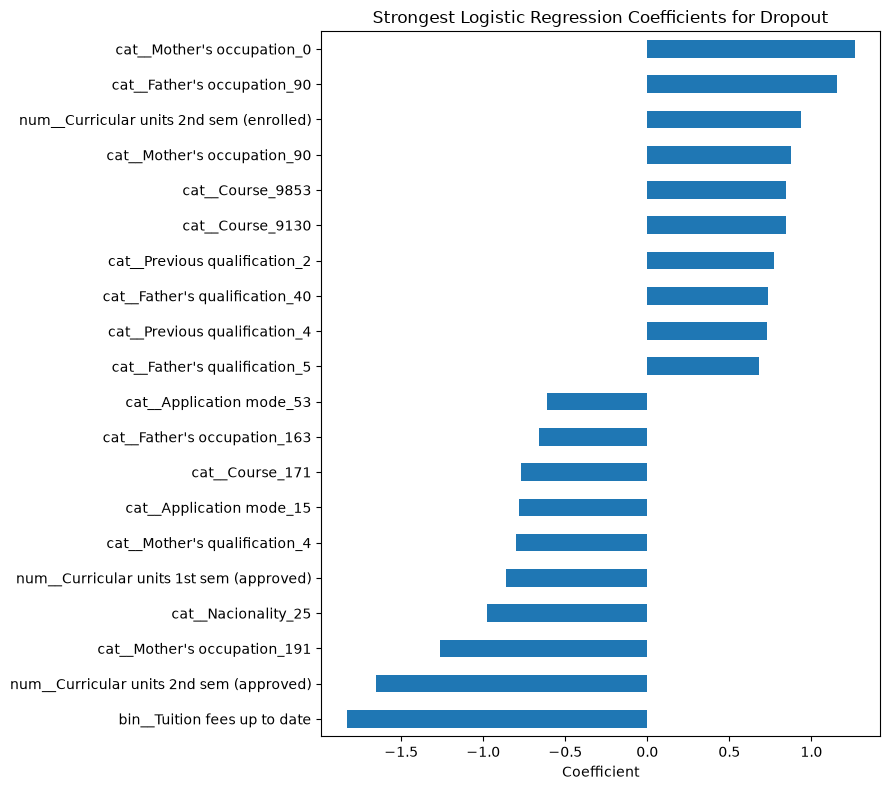

In [9]:
top_dropout_coef = pd.concat([dropout_coef.head(10), dropout_coef.tail(10)]).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
top_dropout_coef.plot(kind="barh", ax=ax)
ax.set_title("Strongest Logistic Regression Coefficients for Dropout")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()
